## `merged_results.ipynb`

-----------------------

This notebook collates the results and plots them. Most methods are accessible in `inference.py`

In [1]:
import numpy as np 
import importlib
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from scipy.integrate import simpson
from pycorr import TwoPointEstimator

import src.statistics.inference as inference
import src.statistics.combination as comb
import src.statistics.cosmotools as ct
import src.statistics.corrfiles as cf
import src.statistics.sgp as sgp

In [2]:
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

In [4]:
stem = 'v14'
path_dictionary = {
    'HSC' : ROOT / 'v12_correction' / f'autos_HSC', # with no wpp correction, is unused
    'DESI_NGC' : ROOT / stem / f'autos_NGC',
    'DESI_SGC' : ROOT / stem / f'autos_SGC',
    'DESIxHSC' : ROOT / stem / f'cross',
}
assert all([p.exists() for p in path_dictionary.values()])
outdir = ROOT / f'merged_{stem}'

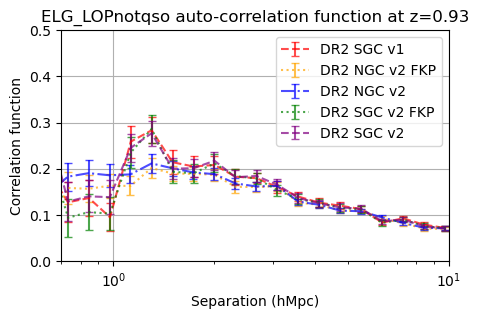

In [10]:
tracer = 'ELG_LOPnotqso'  # 'BGS_ANY', 'LRG', 'ELG_LOPnotqso', 'QSO'
bin_id = 2
tracer_redshifts= {
    'BGS_ANY' : np.arange(0.0, 0.55, 0.05),
    'LRG' : np.arange(0.4, 1.15, 0.05),
    'ELG_LOPnotqso' : np.arange(0.8, 1.65, 0.05),
    'QSO' : np.arange(0.8, 2.85, 0.05),
}
binz = tracer_redshifts[tracer]
midz = (binz[bin_id] + binz[bin_id + 1]) / 2
dr2_v1_SGC = cf.CorrFileReader(ROOT / 'v14' / 'autos_SGC' )
dr2_v2_SGC_w = cf.CorrFileReader(ROOT / 'v21_dr2_v2_w' / 'autos_SGC' )
dr2_v2_SGC_w_fkp = cf.CorrFileReader(ROOT / 'v22_dr2_v2_w_fkp' / 'autos_SGC' )
dr2_v2_NGC_w_fkp = cf.CorrFileReader(ROOT / 'v22_dr2_v2_w_fkp' / 'autos_NGC' )
dr2_v2_NGC_w = cf.CorrFileReader(ROOT / 'v23_dr2_v2_w' / 'autos_NGC' ) 
#OUTDIR="-o outputs/v23_dr2_v2_w/autos_NGC" && DEFAULT_FLAGS="-s 0 -ns 100 -re 256 -j -k -a 1" && setcc && python run_corr.py $OUTDIR -t1 ELG_LOPnotqso $DEFAULT_FLAGS
tpcf_v1_SGC = TwoPointEstimator.load(dr2_v1_SGC.get_file(bin_id, bin_id, tracer, tracer, moc=3))
tpcf_v2_SGC_w_fkp = TwoPointEstimator.load(dr2_v2_SGC_w_fkp.get_file(bin_id, bin_id, tracer, tracer, moc=3))
tpcf_v2_SGC_w = TwoPointEstimator.load(dr2_v2_SGC_w.get_file(bin_id, bin_id, tracer, tracer, moc=3))
tpcf_v2_NGC_w = TwoPointEstimator.load(dr2_v2_NGC_w.get_file(bin_id, bin_id, tracer, tracer, moc=1))
tpcf_v2_NGC_w_fkp = TwoPointEstimator.load(dr2_v2_NGC_w_fkp.get_file(bin_id, bin_id, tracer, tracer, moc=1))

plt.figure(figsize=(5, 3))
plt.title(f'{tracer} auto-correlation function at z={midz:.2f}')

plt.errorbar(ct.arcsec2hMpc(tpcf_v1_SGC.sep * 3600, z=midz), tpcf_v1_SGC.corr,  np.sqrt(np.diag(tpcf_v1_SGC.cov())), label='DR2 SGC v1', capsize=3, color='red', linestyle='--', alpha=0.7)
plt.errorbar(ct.arcsec2hMpc(tpcf_v2_NGC_w_fkp.sep * 3600, z=midz), tpcf_v2_NGC_w_fkp.corr,  np.sqrt(np.diag(tpcf_v2_NGC_w_fkp.cov())), label='DR2 NGC v2 FKP', capsize=3, color='orange', linestyle=':', alpha=0.7)
plt.errorbar(ct.arcsec2hMpc(tpcf_v2_NGC_w.sep * 3600, z=midz), tpcf_v2_NGC_w.corr,  np.sqrt(np.diag(tpcf_v2_NGC_w.cov())), label='DR2 NGC v2', capsize=3, color='blue', linestyle='-.', alpha=0.7)
plt.errorbar(ct.arcsec2hMpc(tpcf_v2_SGC_w_fkp.sep * 3600, z=midz), tpcf_v2_SGC_w_fkp.corr,  np.sqrt(np.diag(tpcf_v2_SGC_w_fkp.cov())), label='DR2 SGC v2 FKP', capsize=3, color='green', linestyle=':', alpha=0.7)
plt.errorbar(ct.arcsec2hMpc(tpcf_v2_SGC_w.sep * 3600, z=midz), tpcf_v2_SGC_w.corr,  np.sqrt(np.diag(tpcf_v2_SGC_w.cov())), label='DR2 SGC v2', capsize=3, color='purple', linestyle='--', alpha=0.7)
plt.xlim(0.7, 10)
plt.ylim(0, 0.5)
plt.legend()
plt.xlabel('Separation (hMpc)')
plt.ylabel('Correlation function')
plt.xscale('log')
plt.grid()

In [ ]:
tracer = 'ELG_LOPnotqso'  # 'BGS_ANY', 'LRG', 'ELG_LOPnotqso', 'QSO'
bin_id = 5
tracer_redshifts= {
    'BGS_ANY' : np.arange(0.0, 0.55, 0.05),
    'LRG' : np.arange(0.4, 1.15, 0.05),
    'ELG_LOPnotqso' : np.arange(0.8, 1.65, 0.05),
    'QSO' : np.arange(0.8, 2.85, 0.05),
}
binz = tracer_redshifts[tracer]
dr1_NGC = cf.CorrFileReader(ROOT / 'v15_dr1' / 'autos_NGC' )
dr2_NGC = cf.CorrFileReader(ROOT / 'v14' / 'autos_NGC' )
dr1_SGC = cf.CorrFileReader(ROOT / 'v15_dr1' / 'autos_SGC' )
dr1_SGC_2 = cf.CorrFileReader(ROOT / 'v17_dr1_comp_w' / 'autos_SGC' )
dr1_SGC_3 = cf.CorrFileReader(ROOT / 'v16_dr1_comp_fkp_w' / 'autos_SGC' )
dr1_SGC_4 = cf.CorrFileReader(ROOT / 'v18_dr1_w' / 'autos_SGC' )
dr1_SGC_5 = cf.CorrFileReader(ROOT / 'v18_dr1_frac_tlobs' / 'autos_SGC' )
dr1_SGC_6 = cf.CorrFileReader(ROOT / 'v19_dr1_fractlobs' / 'autos_SGC' )
dr2_SGC = cf.CorrFileReader(ROOT / 'v14' / 'autos_SGC' )
tpcf_dr1_NGC = TwoPointEstimator.load(dr1_NGC.get_file(bin_id, bin_id, tracer, tracer, 1))
tpcf_dr1_SGC = TwoPointEstimator.load(dr1_SGC.get_file(bin_id, bin_id, tracer, tracer, 3))
tpcf_dr2_SGC = TwoPointEstimator.load(dr2_SGC.get_file(bin_id, bin_id, tracer, tracer, 3))
tpcf_dr1_SGC_2 = TwoPointEstimator.load(dr1_SGC_2.get_file(bin_id, bin_id, tracer, tracer, 3))
tpcf_dr1_SGC_3 = TwoPointEstimator.load(dr1_SGC_3.get_file(bin_id, bin_id, tracer, tracer, 3))
tpcf_dr1_SGC_4 = TwoPointEstimator.load(dr1_SGC_4.get_file(bin_id, bin_id, tracer, tracer, 3))
tpcf_dr1_SGC_5 = TwoPointEstimator.load(dr1_SGC_5.get_file(bin_id, bin_id, tracer, tracer, 3))
tpcf_dr1_SGC_6 = TwoPointEstimator.load(dr1_SGC_6.get_file(bin_id, bin_id, tracer, tracer, 3))
tpcf_dr2_NGC = TwoPointEstimator.load(dr2_NGC.get_file(bin_id, bin_id, tracer, tracer, 1))

Text(0.5, 1.0, 'ELG_LOPnotqso z:1.075')

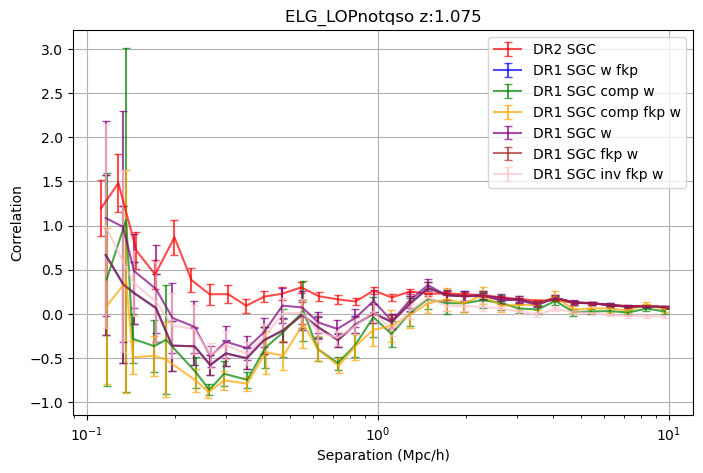

In [16]:
midz = (binz[bin_id] + binz[bin_id + 1]) / 2
plt.figure(figsize=(8, 5))
#plt.errorbar(ct.arcsec2hMpc(tpcf_dr1_NGC.sep * 3600, z=midz), tpcf_dr1_NGC.corr, np.sqrt(np.diag(tpcf_dr1_NGC.cov())), label='DR1 NGC', capsize=3, color='darkblue', linestyle='--', alpha=0.7)
#plt.errorbar(ct.arcsec2hMpc(tpcf_dr2_NGC.sep * 3600, z=midz), tpcf_dr2_NGC.corr, np.sqrt(np.diag(tpcf_dr2_NGC.cov())), label='DR2 NGC', capsize=3, color='darkred', linestyle='--', alpha=0.7)
plt.errorbar(ct.arcsec2hMpc(tpcf_dr2_SGC.sep * 3600, z=midz), tpcf_dr2_SGC.corr, np.sqrt(np.diag(tpcf_dr2_SGC.cov())), label='DR2 SGC', capsize=3, color='red', linestyle='-', alpha=0.7)
plt.errorbar(ct.arcsec2hMpc(tpcf_dr1_SGC.sep * 3600, z=midz), tpcf_dr1_SGC.corr, np.sqrt(np.diag(tpcf_dr1_SGC.cov())), label='DR1 SGC w fkp', capsize=3, color='blue', linestyle='-', alpha=0.7)
plt.errorbar(ct.arcsec2hMpc(tpcf_dr1_SGC_2.sep * 3600, z=midz), tpcf_dr1_SGC_2.corr, np.sqrt(np.diag(tpcf_dr1_SGC_2.cov())), label='DR1 SGC comp w', capsize=3, color='green', linestyle='-', alpha=0.7)
plt.errorbar(ct.arcsec2hMpc(tpcf_dr1_SGC_3.sep * 3600, z=midz), tpcf_dr1_SGC_3.corr, np.sqrt(np.diag(tpcf_dr1_SGC_3.cov())), label='DR1 SGC comp fkp w', capsize=3, color='orange', linestyle='-', alpha=0.7)
plt.errorbar(ct.arcsec2hMpc(tpcf_dr1_SGC_4.sep * 3600, z=midz), tpcf_dr1_SGC_4.corr, np.sqrt(np.diag(tpcf_dr1_SGC_4.cov())), label='DR1 SGC w', capsize=3, color='purple', linestyle='-', alpha=0.7)
plt.errorbar(ct.arcsec2hMpc(tpcf_dr1_SGC_5.sep * 3600, z=midz), tpcf_dr1_SGC_5.corr, np.sqrt(np.diag(tpcf_dr1_SGC_5.cov())), label='DR1 SGC fkp w', capsize=3, color='brown', linestyle='-', alpha=0.7)
plt.errorbar(ct.arcsec2hMpc(tpcf_dr1_SGC_6.sep * 3600, z=midz), tpcf_dr1_SGC_6.corr, np.sqrt(np.diag(tpcf_dr1_SGC_6.cov())), label='DR1 SGC inv fkp w', capsize=3, color='pink', linestyle='-', alpha=0.7)
plt.grid()
plt.xlabel('Separation (Mpc/h)')
plt.ylabel('Correlation')
plt.legend()
plt.xscale('log')
plt.title(f'{tracer} z:{midz:.3f}')

Text(0.5, 1.0, 'ELG_LOPnotqso z:1.075')

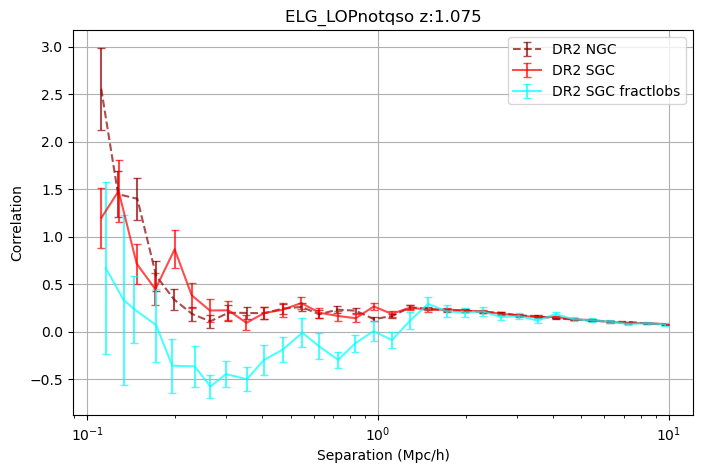

In [16]:
## same thing but only DR2
plt.figure(figsize=(8, 5))
plt.errorbar(ct.arcsec2hMpc(tpcf_dr2_NGC.sep * 3600, z=midz), tpcf_dr2_NGC.corr, np.sqrt(np.diag(tpcf_dr2_NGC.cov())), label='DR2 NGC', capsize=3, color='darkred', linestyle='--', alpha=0.7)
plt.errorbar(ct.arcsec2hMpc(tpcf_dr2_SGC.sep * 3600, z=midz), tpcf_dr2_SGC.corr, np.sqrt(np.diag(tpcf_dr2_SGC.cov())), label='DR2 SGC', capsize=3, color='red', linestyle='-', alpha=0.7)
plt.errorbar(ct.arcsec2hMpc(tpcf_dr1_SGC_5.sep * 3600, z=midz), tpcf_dr1_SGC_5.corr, np.sqrt(np.diag(tpcf_dr1_SGC_5.cov())), label='DR2 SGC fractlobs', capsize=3, color='cyan', linestyle='-', alpha=0.7)
plt.grid()
plt.xlabel('Separation (Mpc/h)')
plt.ylabel('Correlation')
plt.legend()
plt.xscale('log')
plt.title(f'{tracer} z:{midz:.3f}')

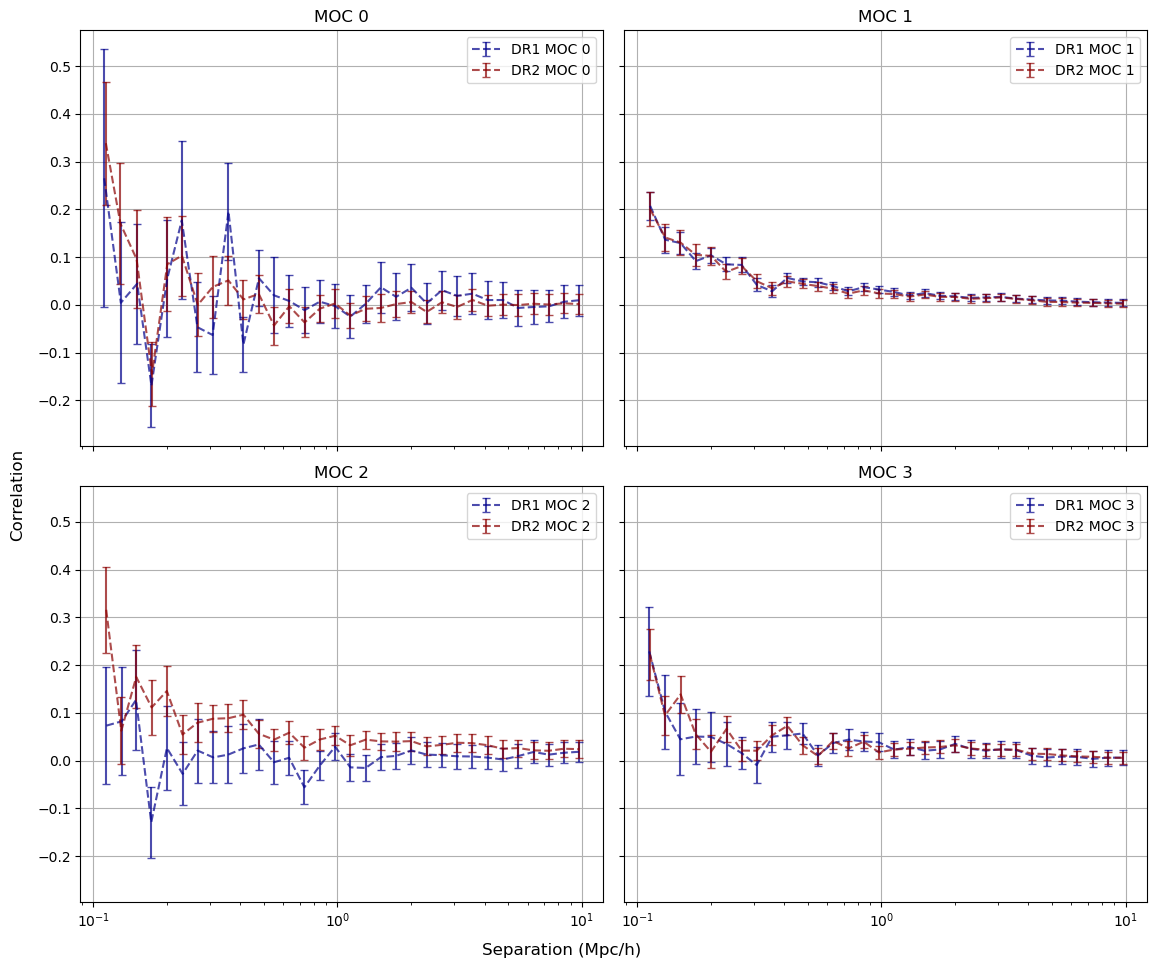

In [35]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
bin_id1 = 1
bin_id2 = 2
tracer_cross = 'ELG_LOPnotqso'  # 'BGS_ANY', 'LRG', 'ELG_LOPnotqso', 'QSO'
binz_cross = tracer_redshifts[tracer_cross]

dr1_cross = cf.CorrFileReader(ROOT / 'v15_dr1' / 'cross')
dr2_cross = cf.CorrFileReader(ROOT / 'v14' / 'cross')
midz = (binz_cross[bin_id1] + binz_cross[bin_id2]) / 2  # corrected index

for moc_id in range(4):
    ax = axs[moc_id // 2, moc_id % 2]
    tpcf_dr1_cross = TwoPointEstimator.load(dr1_cross.get_file(bin_id1, bin_id2, tracer_cross, 'HSC', moc_id))
    tpcf_dr2_cross = TwoPointEstimator.load(dr2_cross.get_file(bin_id1, bin_id2, tracer_cross, 'HSC', moc_id))

    sep_hMpc_dr1 = ct.arcsec2hMpc(tpcf_dr1_cross.sep * 3600, z=midz)
    sep_hMpc_dr2 = ct.arcsec2hMpc(tpcf_dr2_cross.sep * 3600, z=midz)

    ax.errorbar(sep_hMpc_dr1, tpcf_dr1_cross.corr, 
                yerr=np.sqrt(np.diag(tpcf_dr1_cross.cov())), 
                label=f'DR1 MOC {moc_id}', color='darkblue', linestyle='--', alpha=0.7, capsize=3)
    ax.errorbar(sep_hMpc_dr2, tpcf_dr2_cross.corr, 
                yerr=np.sqrt(np.diag(tpcf_dr2_cross.cov())), 
                label=f'DR2 MOC {moc_id}', color='darkred', linestyle='--', alpha=0.7, capsize=3)

    ax.set_xscale('log')
    ax.set_title(f'MOC {moc_id}')
    ax.grid(True)
    ax.legend(fontsize=10, loc='upper right')

# Shared axis labels
fig.text(0.5, 0.04, 'Separation (Mpc/h)', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'Correlation', va='center', rotation='vertical', fontsize=12)
plt.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.show()


In [12]:
print(tpcf_dr1_cross.D1D2.size1)
print(tpcf_dr1_cross.D1D2.size2)
print(tpcf_dr2_cross.D1D2.size1)
print(tpcf_dr2_cross.D1D2.size2)

2048622
2225
2048622
4257


In [23]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(ct)
importlib.reload(cf)
inference.merge_estimators(
    path_dictionary=path_dictionary, 
    outdir=outdir, 
    verbose=True,
    tomo_interest=[1, 2, 3, 4]
    )

Processing redshift bin 0 (Completion : 1.79%)
Processing redshift bin 5 (Completion : 10.71%)
Processing redshift bin 10 (Completion : 19.64%)
Processing redshift bin 15 (Completion : 28.57%)
Processing redshift bin 20 (Completion : 37.50%)
Processing redshift bin 25 (Completion : 46.43%)
Processing redshift bin 30 (Completion : 55.36%)
Processing redshift bin 35 (Completion : 64.29%)
Processing redshift bin 40 (Completion : 73.21%)
Processing redshift bin 45 (Completion : 82.14%)
Processing redshift bin 50 (Completion : 91.07%)
Processing redshift bin 55 (Completion : 100.00%)
Saved cross-correlation estimator to /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/merged_v15_dr1/MergedxHSC/MergedxHSC_b1x1_b2x1.npy
Saved cross-correlation estimator to /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/merged_v15_dr1/MergedxHSC/MergedxHSC_b1x1_b2x2.npy
Saved cross-correlation estimator to /global/cfs/projectdirs/desi/users/jchdj/desi-y3-

In [13]:
outdir = ROOT / 'merged_v15_dr1'
path_dictionary.update({
    'MergedxMerged' : outdir,
    'MergedxHSC' : outdir,
})

In [ ]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(ct)
importlib.reload(cf)
tomobin = 2
tracer = 'LRG'
meas = inference.full_npz_tomo(
    path_dictionary=path_dictionary,
    do_bias_correction=False,
    scale_cuts=[.5, 3],
    tracer=tracer,
    tomo_bin=tomobin,
    rebin=1
)

Using standard method for tracer LRG and tomo bin 2.


In [36]:
importlib.reload(inference)
plt.figure(figsize=(6, 4))
zbins = inference._get_fine_redshift_bins(fr=cf.CorrFileReader(path_dictionary["DESI_NGC"]), tracer=tracer)
#zbins = np.arange(0.8, 2.85, 0.05)  # we only want the first 40 bins, excluding the last two
#zval = (zbins[1:] + zbins[:-1])/2  # we only want the middle values
zbins = tracer_redshifts[tracer]
zval = (zbins[1:] + zbins[:-1])/2
integral = simpson(meas[0], zval)
if integral < 0:
    integral = 1.0
    print(f'Warning: integral of p(z) is negative ({integral}), setting it to 1.0 to avoid division by zero.')
gp = sgp.gpfit(zval, meas/integral)
plt.errorbar(zval, meas[0]/integral, meas[1]/integral, linestyle='', capsize=3, color='red')
plt.fill_between(zval, gp[0] - gp[1], gp[0] + gp[1], color='red', alpha=0.3, label='GP fit')
plt.axhline(0, color='k', linestyle='--')
plt.grid()
plt.xlabel('z', fontsize=16)
plt.ylabel('p(z)', fontsize=16)

print(f'Integrated p(z) = {simpson(meas[0], zval):.3f}')
print(f'Expected p(z) = {simpson(np.multiply(zval, gp[0]), zval):.3f}')

NameError: name 'meas' is not defined

<Figure size 600x400 with 0 Axes>

In [51]:
importlib.reload(ct)
mask = (zval > 0) & (zval < 3) 
#mask = np.ones_like(zval, dtype=bool)  # use all z values

zcen = .5
sigma = 0.16
b = meas[0][mask]

#normal_dist = np.exp(-0.5 * ((zval - zcen) / sigma) ** 2)
#dz = np.diff(zval).mean()
#normal_dist /= np.sum(normal_dist * dz)
#b = normal_dist[mask]

b = meas[0][mask] / simpson(meas[0][mask], zval[mask])
b_err = meas[1][mask] / simpson(meas[0][mask], zval[mask])

npz, npz_err, wdm, Mag, dMag = ct.solve_magnification(
    meas=b,
    meas_err=b_err,
    scale_cut=[.5, 2],
    zvalues=zval[mask],
    return_matrices=True
)

Computing w_dm for 14 redshifts and 101 rp values...
Computing magnification matrix for 14 redshifts...
Solving the linear system for 14 redshifts...


-0.004006590947365957


<Figure size 600x400 with 0 Axes>

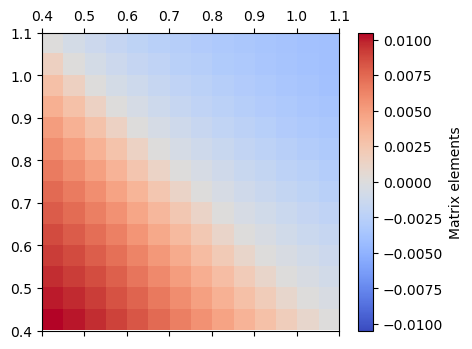

In [52]:
M = Mag - np.diag(np.ones(len(Mag)))
max_abs = np.max(np.abs(M))
plt.figure(figsize=(6, 4))
plt.matshow(M, extent=[0.4, 1.1, 0.4, 1.1], cmap='coolwarm', vmin=-max_abs, vmax=max_abs)
plt.colorbar(label='Matrix elements', shrink=0.8)
print(np.min(M))

In [53]:
importlib.reload(ct)
scale_cut = [.5, 2]
zvalues = zval[mask]
rp_vals = np.linspace(scale_cut[0], scale_cut[1], 100)  # in h^-1 Mpc
print(f'Computing w_dm for {len(zvalues)} redshifts and {len(rp_vals)} rp values...')
w_dm_values = np.array([
    ct.w_dm(rp_vals, z, integrate=False) 
    for z in zvalues
])
w_dm_ang = np.array([
    ct.w_dm_ang(rp_vals, z, integrate=False) 
    for z in zvalues
])

Computing w_dm for 14 redshifts and 100 rp values...


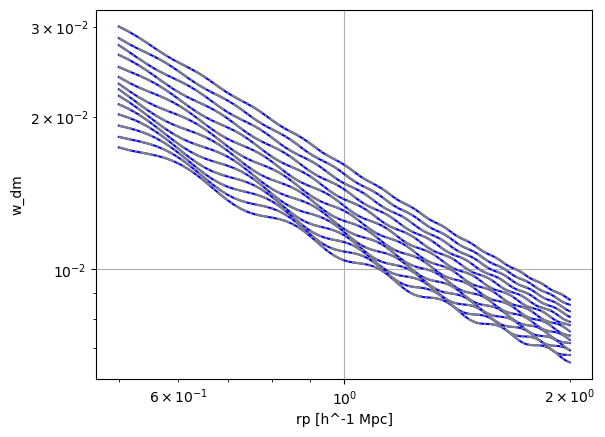

In [54]:
for wdm in w_dm_values:
    plt.plot(rp_vals, wdm, label=f'z={zvalues[0]:.2f}', color='blue')
for wdm_a in w_dm_ang:
    plt.plot(rp_vals, wdm_a*0.05, linestyle='-.', label=f'z={zvalues[0]:.2f} (ang)', color='gray')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('rp [h^-1 Mpc]')
plt.ylabel('w_dm')
plt.grid()

/tmp/ipykernel_712528/2643447822.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


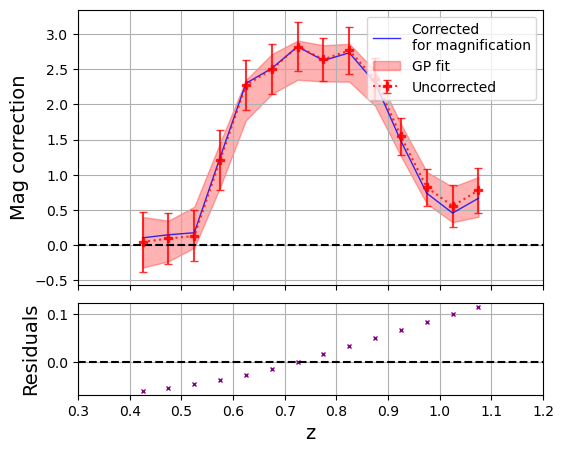

In [56]:
import matplotlib.pyplot as plt

# Compute residuals
residuals = (b - npz) 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), sharex=True, height_ratios=[3, 1], gridspec_kw={'hspace': 0.1})

ax1.errorbar(zval[mask], b, b_err, marker='P', capsize=3, label='Uncorrected', color='red', alpha=0.8, linestyle=':')
ax1.plot(zval[mask], npz, label='Corrected\nfor magnification', linewidth=1, color='blue', alpha=0.8)
ax1.fill_between(zval[mask], gp[0][mask] - gp[1][mask], gp[0][mask] + gp[1][mask], color='red', alpha=0.3, label='GP fit')
ax1.axhline(0, color='k', linestyle='--')
ax1.set_ylabel('Mag correction', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid()
ax1.set_xlim(0.3, 1.2)

# Residuals plot
ax2.plot(zval[mask], residuals, 'x', markersize=3, color='purple')
ax2.axhline(0, color='k', linestyle='--')
ax2.set_xlabel('z', fontsize=14)
ax2.set_ylabel('Residuals', fontsize=14)
ax2.grid()
#ax2.set_ylim(-0.12, 0.12)


plt.tight_layout()
plt.show()


In [36]:
importlib.reload(inference)
importlib.reload(cf)
path_dictionary_correction = {
    'HSC' : ROOT / 'v12_correction' / f'autos_HSC',  # with no wpp correction, is unuse
    'DESI_NGC' : ROOT / 'v12_correction' / f'autos_NGC',
    'DESI_SGC' : ROOT / 'v12_correction' / f'autos_SGC',
    'DESIxHSC' : ROOT / 'v12_correction' / f'cross',
    'MergedxMerged' : ROOT / 'merged_v12_correction',
    'MergedxHSC' : ROOT / 'merged_v12_correction'
}
nz = []
nz_err = []
correction_file_reader = cf.CorrFileReader(path_dictionary_correction["DESI_NGC"])
bins_z = inference._get_fine_redshift_bins(
    fr=correction_file_reader,
    tracer='Merged'
)
bins_hsc = correction_file_reader.get_bins('HSC')
print(bins_hsc)
for i in range(1, len(bins_hsc)):
    print(f'Processing tomo bin {i}')
    meas = inference.full_npz_tomo(
        path_dictionary=path_dictionary_correction,
        do_bias_correction=False,
        scale_cuts=[.3, 2.5],
        tracer='Merged',
        tomo_bin=i,
    )
    nz.append(meas[0])
    nz_err.append(meas[1])
nz = np.array(nz)
nz_err = np.array(nz_err)

[0.   0.12 0.24 0.36 0.48 0.6  0.72 0.84 0.96 1.08 1.2  1.32 1.44 1.56
 1.68 1.8  1.92 2.04 2.16 2.28 2.4 ]
Processing tomo bin 1
Using merged method for tracer Merged and tomo bin 1.
Processing tomo bin 2
Using merged method for tracer Merged and tomo bin 2.
Processing tomo bin 3
Using merged method for tracer Merged and tomo bin 3.
Processing tomo bin 4
Using merged method for tracer Merged and tomo bin 4.
Processing tomo bin 5
Using merged method for tracer Merged and tomo bin 5.
Processing tomo bin 6
Using merged method for tracer Merged and tomo bin 6.
Processing tomo bin 7
Using merged method for tracer Merged and tomo bin 7.
Processing tomo bin 8
Using merged method for tracer Merged and tomo bin 8.
Processing tomo bin 9
Using merged method for tracer Merged and tomo bin 9.
Processing tomo bin 10
Using merged method for tracer Merged and tomo bin 10.
Processing tomo bin 11
Using merged method for tracer Merged and tomo bin 11.
Processing tomo bin 12
Using merged method for trace

63 63
63 63
63 63
63 63
63 63
63 63
63 63
63 63
63 63
63 63


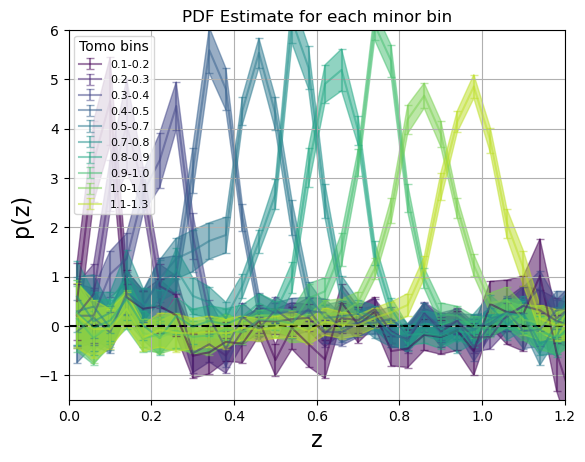

In [ ]:
stds = []
viridis = plt.get_cmap('viridis')
tomo_bin = [0, 1.2]
tomo_vals = (bins_hsc[1:] + bins_hsc[:-1])/2
zval = (bins_z[1:] + bins_z[:-1])/2 
dz = 0.1
haserr = True
plotted_indices = []

for i in range(nz.shape[0]):
    if tomo_vals[i] > tomo_bin[1]-dz/2 or tomo_vals[i] < tomo_bin[0]-dz/2:
        continue
    plotted_indices.append(i)

for num, i in enumerate(plotted_indices):
    integrated_nz = simpson(nz[i], zval)
    stds.append(np.std(nz[i]/integrated_nz))
    if haserr:
        plt.errorbar(
            zval, 
            nz[i], 
            nz_err[i], 
            label=f'{tomo_vals[i]:.1f}-{tomo_vals[i+1]:.1f}', 
            alpha=0.5,
            color=viridis(num/len(plotted_indices)), 
            capsize=3
        )
    
    plt.fill_between(
        zval, 
        (nz[i] - nz_err[i]), 
        (nz[i] + nz_err[i]), 
        alpha=0.5,
        color=viridis(num/len(plotted_indices)), 
        #label=f'{stds[i]:.2f}', 
    )
plt.xlim(0., 1.2)
plt.ylim(-1.5, 6)
plt.grid()
plt.xlabel('z', fontsize=16)
plt.ylabel('p(z)', fontsize=16)
plt.legend(loc='upper left', fontsize=8, title='Tomo bins')
plt.title('PDF Estimate for each minor bin')
plt.axhline(0, color='k', linestyle='--')

zeff = [0.09860381 0.19131671 0.32667667 0.43421602 0.54701895 0.66245985
 0.7883621  0.90576065 1.0202236  1.1460528  1.2602623  1.3818929
 1.5008993  1.6199856  1.7443753  1.8636682  1.9816954  2.1022532
 2.2237961  2.3453999 ]


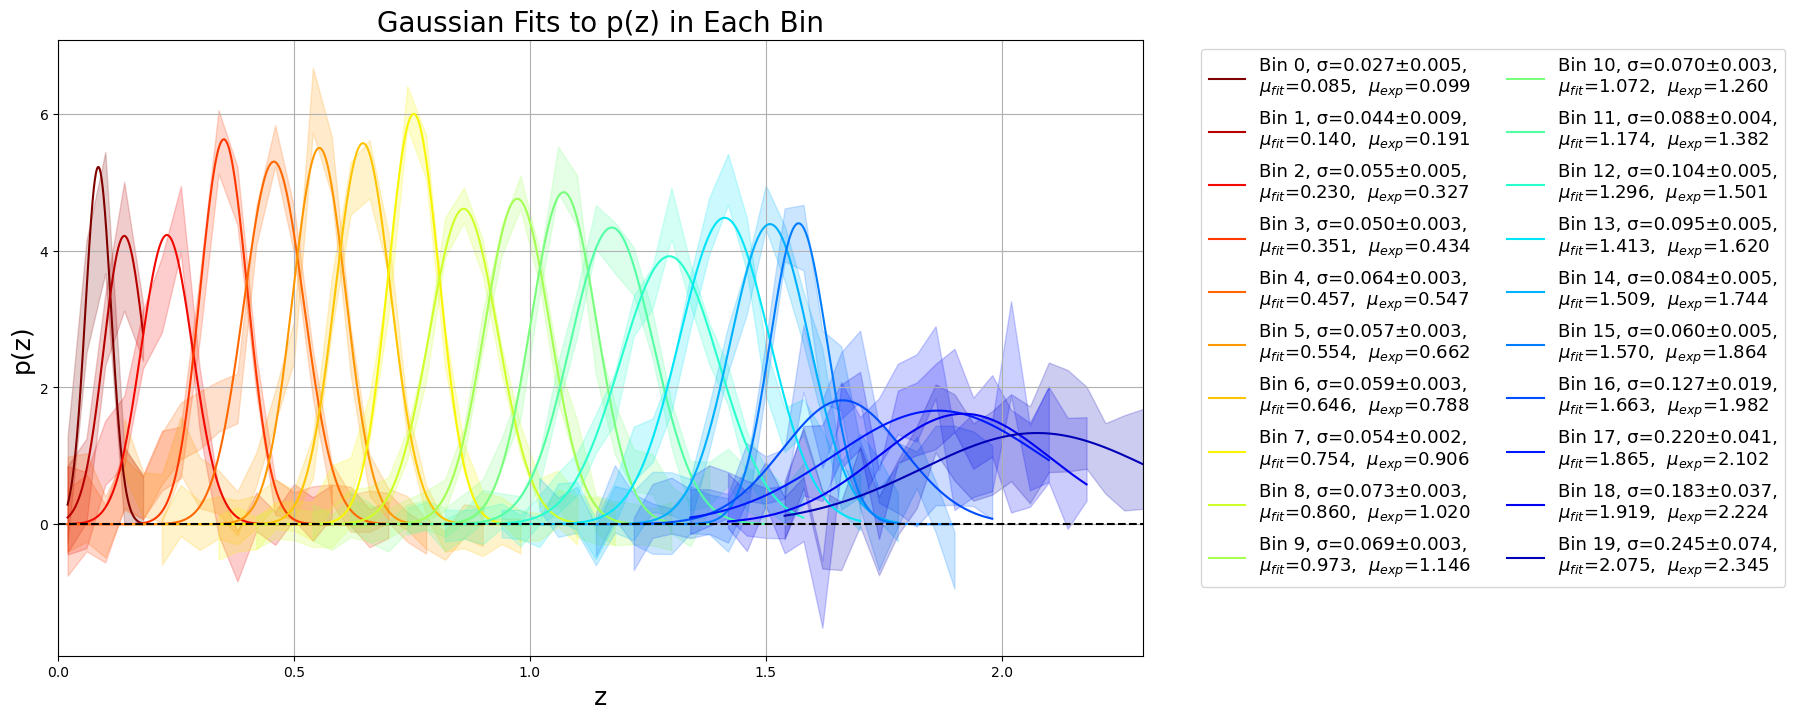

Bin 1: mean = 0.0851, std = 0.0270 ± 0.0054, meas_std = 167.6562
Bin 2: mean = 0.1402, std = 0.0439 ± 0.0091, meas_std = 2.4466
Bin 3: mean = 0.2305, std = 0.0546 ± 0.0053, meas_std = 1.6691
Bin 4: mean = 0.3512, std = 0.0502 ± 0.0030, meas_std = 1.4251
Bin 5: mean = 0.4572, std = 0.0639 ± 0.0034, meas_std = 1.3710
Bin 6: mean = 0.5537, std = 0.0565 ± 0.0028, meas_std = 1.2807
Bin 7: mean = 0.6461, std = 0.0591 ± 0.0027, meas_std = 1.4388
Bin 8: mean = 0.7537, std = 0.0541 ± 0.0023, meas_std = 1.5981
Bin 9: mean = 0.8595, std = 0.0726 ± 0.0028, meas_std = 1.2270
Bin 10: mean = 0.9734, std = 0.0694 ± 0.0031, meas_std = 1.2101
Bin 11: mean = 1.0716, std = 0.0700 ± 0.0033, meas_std = 0.9530
Bin 12: mean = 1.1737, std = 0.0885 ± 0.0043, meas_std = 0.8789
Bin 13: mean = 1.2958, std = 0.1044 ± 0.0054, meas_std = 0.9666
Bin 14: mean = 1.4126, std = 0.0955 ± 0.0049, meas_std = 1.0464
Bin 15: mean = 1.5090, std = 0.0842 ± 0.0051, meas_std = 1.0057
Bin 16: mean = 1.5696, std = 0.0604 ± 0.0050, m

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import simpson
cmap = plt.get_cmap('jet_r')

# Gaussian model
def gaussian(z, A, mu, sigma):
    return A * np.exp(-0.5 * ((z - mu) / sigma)**2)

means = []
stds = []
meas_stds = []
stds_err = [] 

plt.figure(figsize=(14, 8))

hsc_redshifts = np.load('zeff/hsc_z_clustering_catalogs.npy')
zeff = np.array(
    [np.mean(hsc_redshifts[(i*0.12 < hsc_redshifts) & (hsc_redshifts <= (i+1)*0.12)]) for i in range(nz.shape[0])]
)
print(f'zeff = {zeff}')

for i in range(nz.shape[0]):
    if i == 0:
        mask_redshift = (zval >= 0) & (zval <= 0.2)
    elif i == 1:
        mask_redshift = (zval >= 0.) & (zval <= 0.2)
    else:
        mask_redshift = (zval >= (i-4)*0.1) & (zval <= (i+4)*0.1)
    mask = ~np.isnan(nz[i]) & mask_redshift # Mask NaN values and restrict to z range
    z = zval[mask]
    y = nz[i][mask]
    yerr = nz_err[i][mask]

    # Initial guess
    A0 = np.max(y)
    mu0 = np.sum(z * y) / np.sum(y)
    sigma0 = np.sqrt(np.sum(y * (z - mu0)**2) / np.sum(y))

    try:
        popt, pcov = curve_fit(
            gaussian, z, y, p0=[A0, mu0, sigma0], sigma=yerr, absolute_sigma=True
        )
        A_fit, mu_fit, sigma_fit = popt
        sigma_fit_err = np.sqrt(pcov[2, 2])  # <-- get std error

        # Store results
        means.append(mu_fit)
        stds.append(sigma_fit)
        stds_err.append(sigma_fit_err)  # <-- store std error

        zfit = np.linspace(z.min(), z.max(), 300)
        color = cmap(i / nz.shape[0])  # Use colormap for color cycling
        plt.plot(
            zfit, 
            gaussian(zfit, *popt), 
            label=(
                f'Bin {i}, σ={sigma_fit:.3f}±{sigma_fit_err:.3f},\n' 
                + r'$\mu_{fit}$' 
                + f'={mu_fit:.3f},  ' 
                + r'$\mu_{exp}$'
                + f'={zeff[i]:.3f}'
            ), 
            color=color
        )
        plt.fill_between(z, y - yerr, y + yerr, alpha=0.2, color=color)

    except RuntimeError:
        print(f"Fit failed for bin {i}")
        means.append(np.nan)
        stds.append(np.nan)
        stds_err.append(np.nan)
    meas_stds.append(np.std(nz[i] / simpson(nz[i], zval)))

plt.grid()
plt.xlabel('z', fontsize=18)
plt.ylabel('p(z)', fontsize=18)
plt.title('Gaussian Fits to p(z) in Each Bin', fontsize=20)
plt.axhline(0, color='k', linestyle='--')
plt.legend(ncols=2, fontsize=13, loc='upper right', bbox_to_anchor=(1.6, 1.0))
plt.xlim(0, 2.3)
plt.show()

# Final results
for i, (m, s, ms, s_err) in enumerate(zip(means, stds, meas_stds, stds_err)):
    print(f"Bin {i+1}: mean = {m:.4f}, std = {s:.4f} ± {s_err:.4f}, meas_std = {ms:.4f}")

Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calcu

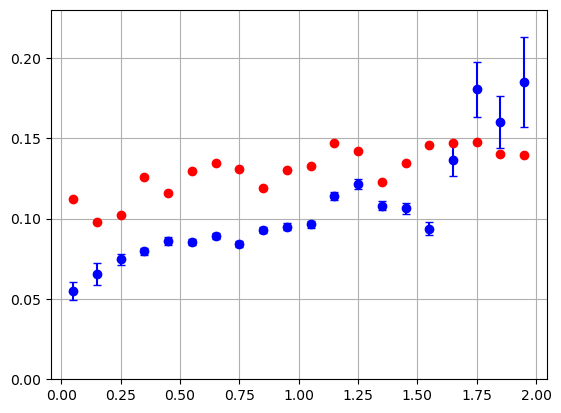

In [ ]:
importlib.reload(inference)
importlib.reload(comb)
wpp = []
wpp_err = []
zeff = []
for i in range(1, len(stds)+1):
    ## now let's get the wpp measurements to get the full correction
    wpp_meas, wpp_err_meas, _ = inference.wpp(
            path=path_dictionary['HSC'],
            scale_cuts=[.2, 3],
            bin_index=i,
        )
    wpp_err.append(wpp_err_meas)
    wpp.append(wpp_meas)
    zeff.append(cf.get_zeff(zlow=(i-1)*0.1, zhigh=i*0.1, type='HSC', scheme='simple'))
print(f'zeff = {zeff}')
print(f'wpp = {wpp}')
print(f'wpp_err = {wpp_err}')
errs = comb.combine_error_bars_mult(wpp, wpp_err, stds, stds_err)
vals = np.sqrt(np.array(wpp)*np.array(stds))
#plt.plot(means, np.sqrt(np.array(wpp)*np.array(stds)), label='wpp')
plt.errorbar(zeff, vals, errs, label='correction', capsize=3, fmt='o', color='blue')
plt.errorbar(zeff, wpp, wpp_err, label='wpp', capsize=3, fmt='o', color='red')
plt.ylim(0, 0.23)
plt.grid()

Number of non-NaN values: 20

Fitted power law:
  a = 0.06444603635845615 ± 0.0014841360379849915
  gamma = 0.6105475676920177 ± 0.03521149667406503


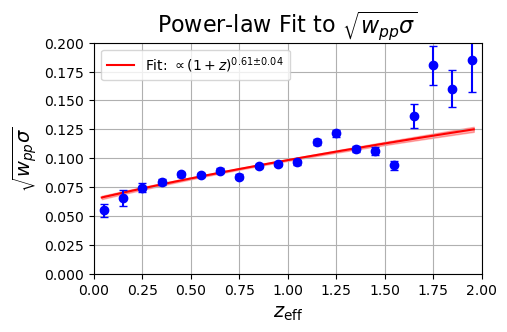

In [52]:
from scipy.optimize import curve_fit

def power_law(z, a, gamma):
    return a * (1 + z)**gamma

# Var(f) ≈ (df/da)^2 * Var(a) + (df/dγ)^2 * Var(γ) + 2*Cov(a,γ)*df/da*df/dγ
def power_law_error(z, a, gamma, pcov):
    da = (1 + z)**gamma
    dgamma = a * (1 + z)**gamma * np.log(1 + z)
    var = (
        da**2 * pcov[0, 0] +
        dgamma**2 * pcov[1, 1] +
        2 * da * dgamma * pcov[0, 1]
    )
    return np.sqrt(var)

nonnan_mask = ~np.isnan(np.array(vals))
print(f"Number of non-NaN values: {np.sum(nonnan_mask)}")
zeff_arr = np.array(zeff)[nonnan_mask]
vals_arr = np.array(vals)[nonnan_mask]
errs_arr = np.array(errs)[nonnan_mask]

p0 = [np.mean(vals_arr), 1.0]

popt, pcov = curve_fit(
    power_law, zeff_arr, vals_arr, p0=p0, sigma=errs_arr, absolute_sigma=True
)
a_fit, gamma_fit = popt
a_err, gamma_err = np.sqrt(np.diag(pcov))

print(f"\nFitted power law:\n  a = {a_fit} ± {a_err}\n  gamma = {gamma_fit} ± {gamma_err}")

# Create fit curve and error band
z_plot = np.linspace(min(zeff_arr)-0.01, max(zeff_arr)+0.01, 300)

fit_vals = power_law(z_plot, a_fit, gamma_fit)
fit_errs = power_law_error(z_plot, a_fit, gamma_fit, pcov)

plt.figure(figsize=(5, 3))

dz = 1
plt.plot(z_plot, fit_vals/dz, 'r-', label=fr'Fit: $\propto(1+z)^{{{gamma_fit:.2f}±{gamma_err:.2f}}}$')
plt.fill_between(z_plot, (fit_vals - fit_errs)/dz, (fit_vals + fit_errs)/dz, color='red', alpha=0.3)#, label='Fit ±1σ')

plt.ylim(0, 0.2)
plt.xlim(0, 2)
plt.legend()
plt.ylabel(r'$\sqrt{w_{pp}\sigma}$', fontsize=14)
plt.errorbar(zeff, vals/dz, errs/dz, label='wpp', capsize=3, fmt='o', color='blue')
plt.xlabel(r'$z_{\rm eff}$', fontsize=14)
plt.title('Power-law Fit to ' + r'$\sqrt{w_{pp}\sigma}$', fontsize=16)
plt.grid()
plt.show()

# Tail removal plots

In [154]:
stem = 'v9_symexpr_20_excl'
path_dictionary = {
    'HSC' : ROOT / 'v12_correction' / f'autos_HSC', # with no wpp correction, is unused
    'DESI_NGC' : ROOT / 'v10' / f'autos_NGC',
    'DESI_SGC' : ROOT / 'v10' / f'autos_SGC',
    'DESIxHSC' : ROOT / stem / f'cross',
}
assert all([p.exists() for p in path_dictionary.values()])
outdir = ROOT / f'merged_{stem}'
path_dictionary.update({
    'MergedxMerged' : outdir,
    'MergedxHSC' : outdir,
})

In [165]:
importlib.reload(inference)
importlib.reload(comb)
inference.merge_estimators(
    path_dictionary=path_dictionary, 
    outdir=outdir, 
    tomo_interest=[3],
)

Processing redshift bin 0 (Completion : 1.79%)
Processing redshift bin 5 (Completion : 10.71%)
Processing redshift bin 10 (Completion : 19.64%)
Processing redshift bin 15 (Completion : 28.57%)
Processing redshift bin 20 (Completion : 37.50%)
Processing redshift bin 25 (Completion : 46.43%)
Processing redshift bin 30 (Completion : 55.36%)
Processing redshift bin 35 (Completion : 64.29%)
Processing redshift bin 40 (Completion : 73.21%)
Processing redshift bin 45 (Completion : 82.14%)
Processing redshift bin 50 (Completion : 91.07%)
Processing redshift bin 55 (Completion : 100.00%)


zeff = [0.0347693  0.07759296 0.12665131 0.17575151 0.22482497 0.27404603
 0.32393083 0.37330081 0.42347698 0.47350585 0.52557593 0.57538912
 0.62527369 0.67527805 0.72542612 0.7758609  0.82548476 0.87483143
 0.92488506 0.9743975  1.02408659 1.07442255 1.12495753 1.1749018
 1.22475909 1.27483098 1.32495408 1.3747339  1.42491349 1.47396121
 1.52443496 1.57456234 1.62520736 1.6749617  1.72500914 1.77491857
 1.82501929 1.87496822 1.92492935 1.97466114 2.02475569 2.074603
 2.12482457 2.17456537 2.22471904 2.27458471 2.3243192  2.37479401
 2.42459292 2.47467053 2.52491472 2.57436009 2.62482698 2.67448626
 2.72458    2.77455367]
Using merged method for tracer Merged and tomo bin 1.
Using merged method for tracer Merged and tomo bin 2.
Using merged method for tracer Merged and tomo bin 3.
Using merged method for tracer Merged and tomo bin 4.
Tomo 1 :
0.47042855509662795
-0.2087508639167375

Tomo 2 :
0.7636079241915921
0.5116686386174458

Tomo 3 :
1.062210326200589
1.0130279709271222

Tomo 4 :

(-1.2, 4.4)

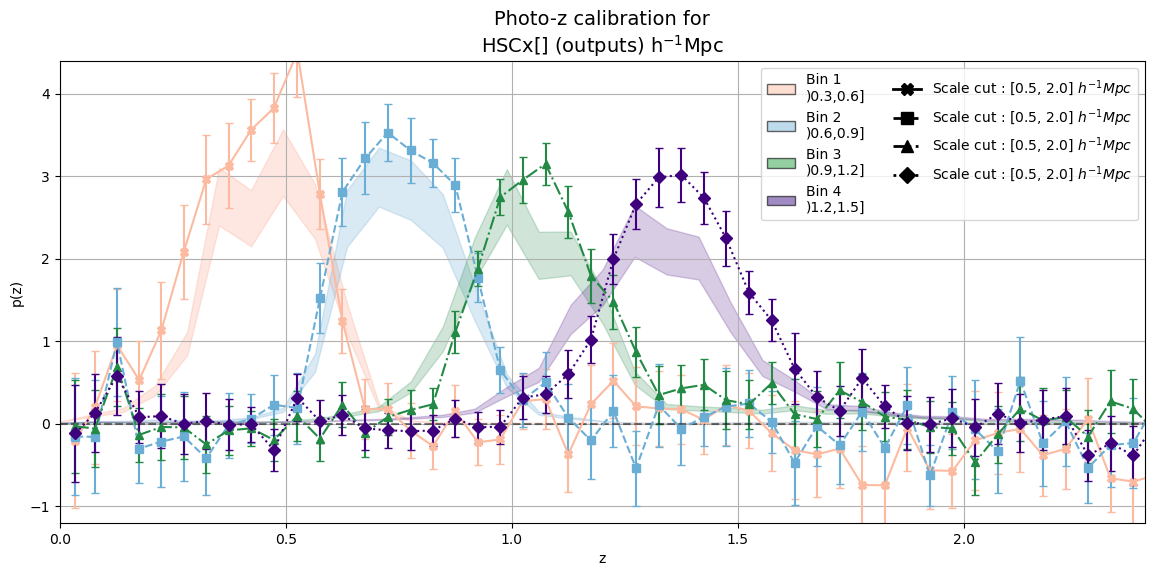

In [ ]:
importlib.reload(inference)
importlib.reload(ct)
ncurves = 0
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

bins_hsc = np.arange(0.3, 1.8, 0.3)

colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['X', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, ax = plt.subplots(figsize=(14, 6))

scale_cut = [0.5, 2]  # scale cuts for the analysis

tomo_interest = [1,2,3,4]  # tomographic bins of interest
title = 'Photo-z calibration for\nHSCx['
zbins = inference._get_fine_redshift_bins(fr=cf.CorrFileReader(path_dictionary["DESI_NGC"]))
redshifts = np.load('zeff/desi_z_clustering_catalogs.npy')
zeff = np.array(
    [np.mean(redshifts[(zbins[i] < redshifts) & (redshifts <= zbins[i+1])]) for i in range(len(zbins)-1)]
)
print(f'zeff = {zeff}')

nz = []
nz_err = []
for tomo in tomo_interest:
    tomo_nz, tomo_nz_err = inference.full_npz_tomo(
        do_bias_correction=False,
        path_dictionary=path_dictionary,
        scale_cuts=scale_cut,
        tracer="Merged",
        tomo_bin=tomo,
        rebin=1,
        )
    nonnanz = ~np.isnan(tomo_nz)
    tomo_nz = tomo_nz[nonnanz]
    tomo_nz_err = tomo_nz_err[nonnanz]
    zval = zeff[nonnanz]
    nz_int = simpson(tomo_nz, x=zval)
    nz.append(tomo_nz/nz_int)
    nz_err.append(tomo_nz_err/nz_int)
    tomo_index = tomo-1 if len(tomo_interest) > 1 else 0
    ax.errorbar(
        x=zval, 
        y=nz[tomo_index],
        yerr=nz_err[tomo_index],#/normalization, 
        capsize=3,
        marker=markers[tomo_index], 
        linestyle=linestyles[tomo_index],
        markersize=6,   
        alpha=1,
        color=colormaps[tomo_index]((tomo)/4),
        )
    
mids = tomo_bin_dnnz[:, 0]

dnnz_list = []
mu_list = []
cov_list = []

ids_to_skip = []

for dnnz_idx in range(0, 4):
    ncurves += 1

    dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, dnnz_idx+1], mids)
    dnnz_list.append(np.percentile(dnnz, 50, axis=0))
    mu_list.append(mu)
    cov_list.append(cov)

    ax.fill_between(
        mids, 
        np.percentile(dnnz, 16, axis=0), 
        np.percentile(dnnz, 84, axis=0), 
        color=colormaps[dnnz_idx]((dnnz_idx+2)/5), 
        alpha=0.2
        )
        
title+=f'] ({ROOT.name}) ' +r'$\rm{h}^{-1}\rm{Mpc}$'
ax.set_xlabel('z')
ax.set_ylabel('p(z)')

legend_elements = []

for bin_id in tomo_interest:
    patch = Patch(
        facecolor=colormaps[bin_id-1](bin_id/len(bins_hsc)),
        alpha=0.6,
        edgecolor='black',
        label=f'Bin {bin_id}\n){bins_hsc[bin_id-1]:.1f},{bins_hsc[bin_id]:.1f}]',
    )
    legend_elements.append(patch)

for i, (marker, linestyle, tracer) in enumerate(zip(markers, linestyles, tracers)):
    element = Line2D(
        [0], 
        [0], 
        color='black', 
        marker=marker, 
        linestyle=linestyle, 
        markersize=8, 
        label=f'Scale cut : [{scale_cut[0]:.1f}, {scale_cut[1]:.1f}] ' + r'$h^{-1}Mpc$', 
        linewidth=2
    )
    legend_elements.append(element)

ax.legend(
    handles=legend_elements, 
    loc='upper right', 
    ncol=2, 
    fontsize=10,
)

for i in range(len(nz)):
    print(f'Tomo {i+1} :')
    assert len(nz[i]) == len(zval), f'Length mismatch for tomo {i+1}'
    print(f'{simpson(np.multiply(mids, dnnz_list[i]), x=mids)}')
    print(f'{simpson(np.multiply(nz[i], zval), x=zval)}\n')

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.grid()
ax.set_title(title, fontsize=14)
ax.set_xlim(0, 2.4)
ax.set_ylim(-1.2, 4.4)

## Gaussian Process Models

In [49]:
stem = 'v15_dr1'
outdir = ROOT / f'merged_{stem}'
path_dictionary = {
    'HSC' : ROOT / 'v11_correction' / f'autos_HSC', # with no wpp correction, is unused
    'DESI_NGC' : ROOT / stem / f'autos_NGC',
    'DESI_SGC' : ROOT / stem / f'autos_SGC',
    'DESIxHSC' : ROOT / stem / f'cross',
    'MergedxMerged' : outdir,
    'MergedxHSC' : outdir,
}

In [38]:
inference.merge_estimators(
    path_dictionary=path_dictionary, 
    outdir=outdir, 
    tomo_interest=[1, 2, 3, 4],
    verbose=True,
)

Processing redshift bin 0 (Completion : 1.79%)
Processing redshift bin 5 (Completion : 10.71%)
Processing redshift bin 10 (Completion : 19.64%)
Processing redshift bin 15 (Completion : 28.57%)
Processing redshift bin 20 (Completion : 37.50%)
Processing redshift bin 25 (Completion : 46.43%)
Processing redshift bin 30 (Completion : 55.36%)
Processing redshift bin 35 (Completion : 64.29%)
Processing redshift bin 40 (Completion : 73.21%)
Processing redshift bin 45 (Completion : 82.14%)
Processing redshift bin 50 (Completion : 91.07%)
Processing redshift bin 55 (Completion : 100.00%)
Saved cross-correlation estimator to /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/merged_v14/MergedxHSC/MergedxHSC_b1x1_b2x1.npy
Saved cross-correlation estimator to /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/merged_v14/MergedxHSC/MergedxHSC_b1x1_b2x2.npy
Saved cross-correlation estimator to /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/

Using merged method for tracer Merged and tomo bin 1.
GP kernel: 0.944**2 * Matern(length_scale=0.1, nu=1.5)
Using merged method for tracer Merged and tomo bin 2.
GP kernel: 0.972**2 * Matern(length_scale=0.1, nu=1.5)
Using merged method for tracer Merged and tomo bin 3.
GP kernel: 0.645**2 * Matern(length_scale=0.1, nu=1.5)
Using merged method for tracer Merged and tomo bin 4.
GP kernel: 0.656**2 * Matern(length_scale=0.1, nu=1.5)


(-1.0, 4.5)

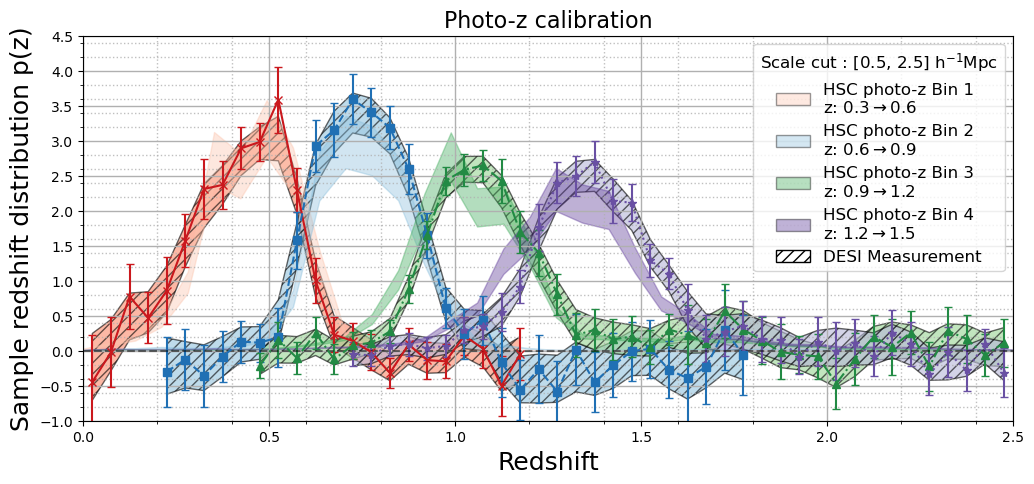

In [ ]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(sgp)
ncurves = 0
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELG_LOPnotqso' : 'ELG',
    'QSO' : 'QSO',
}

bins_hsc = np.arange(0.3, 1.8, 0.3)

colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['x', 's', '^', '*']
linestyles = ['-', '--', '-.', ':']
tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, ax = plt.subplots(figsize=(12, 5))

scale_cut = [.5, 2.5]

tomo_interest = [1,2,3,4]  # tomographic bins of interest
title = 'Photo-z calibration'
zbins = inference._get_fine_redshift_bins(fr=cf.CorrFileReader(path_dictionary["DESI_NGC"]))
redshifts = np.load('zeff/desi_z_clustering_catalogs.npy')
zeff = np.array(
    [np.mean(redshifts[(zbins[i] < redshifts) & (redshifts <= zbins[i+1])]) for i in range(len(zbins)-1)]
)
zeff = (zbins[1:] + zbins[:-1]) / 2  # use the midpoints of the bins as effective redshifts

nz = []
nz_err = []
for tomo_index, tomo in enumerate(tomo_interest):
    tomo_nz, tomo_nz_err = inference.full_npz_tomo(
        path_dictionary=path_dictionary,
        scale_cuts=scale_cut,
        do_bias_correction=False,
        tracer="Merged",
        tomo_bin=tomo,
        rebin=1,
        )
    if tomo == 1:
        zmask = (zeff >=0) & (zeff <= 1.2)
    if tomo > 1:
        zmask = (zeff >=0.2)
        if tomo == 2:
            zmask &= (zeff <= 1.8)
        if tomo == 3:
            zmask = (zeff >=0.45) & (zeff <= 2.5)
        if tomo == 4:
            zmask = (zeff >=0.7) & (zeff <= 2.5)


    nonnanz = ~np.isnan(tomo_nz)
    mask_tomo = nonnanz & zmask
    tomo_nz = tomo_nz[mask_tomo]
    tomo_nz_err = tomo_nz_err[mask_tomo]
    zval = zeff[mask_tomo]
    nz_int = simpson(tomo_nz, x=zval)
    nz.append(tomo_nz/nz_int)
    nz_err.append(tomo_nz_err/nz_int)

    dz = np.diff(zval)[0]
    y_mean, y_std = sgp.gpfit(zval, (tomo_nz/nz_int, tomo_nz_err/nz_int))

    ax.fill_between(
        zval,
        y_mean - y_std,
        y_mean + y_std,
        alpha=0.6,
        color=colormaps[tomo-1](0.4),
        edgecolor='black',
        label=f'GP',
        hatch='///'
    )

    ax.errorbar(
        x=zval, 
        y=nz[tomo-1 if len(tomo_interest) > 1 else tomo_index],
        yerr=nz_err[tomo-1 if len(tomo_interest) > 1 else tomo_index],#/normalization, 
        capsize=3,
        marker=markers[tomo-1], 
        linestyle=linestyles[tomo-1],
        markersize=6,   
        alpha=1,
        color=colormaps[tomo-1](3/4),
        )
        
    #title+= f'x{tracer_trad[tracers[tomo-1]]}'

mids = tomo_bin_dnnz[:, 0]
mask_mids = mids < 2.725

dnnz_list = []
mu_list = []
cov_list = []

ids_to_skip = []

for dnnz_idx in range(1, 5):
    if dnnz_idx not in tomo_interest:
        continue
    ncurves += 1
    
    dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, dnnz_idx], mids)
    dnnz_list.append(np.percentile(dnnz, 50, axis=0))
    mu_list.append(mu)
    cov_list.append(cov)

    if len(tomo_interest) == 1:
        col = 'gray'
    else:
        col = colormaps[dnnz_idx-1]((dnnz_idx+0.1)/len(bins_hsc))

    ax.fill_between(
        mids, 
        np.percentile(dnnz, 16, axis=0), 
        np.percentile(dnnz, 84, axis=0), 
        color=col, 
        alpha=0.4
        )
        
#title+=f'] ' +r'$\rm{h}^{-1}\rm{Mpc}$'
ax.set_xlabel('Redshift', fontsize=18)
ax.set_ylabel('Sample redshift distribution p(z)', fontsize=18)

legend_elements = []

for bin_id in tomo_interest:
    if len(tomo_interest) == 1:
        col = 'gray'
    else:
        col = colormaps[bin_id-1](bin_id/len(bins_hsc))
    patch = Patch(
        facecolor=col,
        alpha=0.4,
        edgecolor='black',
        label=f'HSC photo-z Bin {bin_id}\n'
        #+ r'$\mathcal{L}_{\mathrm{\tt{DNNz}}}$' 
        + f'z: {bins_hsc[bin_id-1]:.1f}' +r'$\rightarrow$' + f'{bins_hsc[bin_id]:.1f}',
    )
    legend_elements.append(patch)
legend_elements.append(Patch(
        facecolor='white',
        edgecolor='black',
        label='DESI Measurement',
        hatch='///',
    ))

for i, (marker, linestyle, tracer) in enumerate(zip(markers, linestyles, tracers)):
    if i+1 not in tomo_interest:
        continue
    element = Line2D(
        [0], 
        [0], 
        color='black', 
        marker=marker, 
        linestyle=linestyle, 
        markersize=8, 
        label=f'Scale cut : [{scale_cut[0]:.1f}, {scale_cut[1]:.1f}] ' + r'h$^{-1}$Mpc', 
        linewidth=2
    )
    #legend_elements.append(element)

ax.legend(
    handles=legend_elements, 
    loc='upper right', 
    ncol=1 if len(tomo_interest) == 1 else 1, 
    fontsize=12 if len(tomo_interest) == 1 else 12,
    title=f'Scale cut : [{scale_cut[0]:.1f}, {scale_cut[1]:.1f}] ' + r'h$^{-1}$Mpc',
    title_fontsize=14 if len(tomo_interest) == 1 else 12,
)

#for i in range(len(nz)):
#    print(f'Tomo {i+1} :')
#    assert len(nz[i]) == len(zval), f'Length mismatch for tomo {i+1}'
#    print(f'{simpson(np.multiply(mids, dnnz_list[i]), x=mids)}')
#    print(f'{simpson(np.multiply(nz[i], zval), x=zval)}\n')

ax.axhline(0, color='black', linestyle='--', alpha=0.5)

# X-axis: major ticks every 0.5, minor every 0.2
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.set_minor_locator(MultipleLocator(0.2))

# Y-axis: major ticks every 0.5, minor every 0.2
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.2))

# Grid styling
ax.grid(which='major', linestyle='-', linewidth=1)
ax.grid(which='minor', linestyle=':', linewidth=1, alpha=0.8)

ax.set_title(title, fontsize=16)
ax.set_xlim(0., 2.5)
ax.set_ylim(-1, 4.5)

Tracer BGS_ANY
[0.025 0.075 0.125 0.175 0.225 0.275 0.325 0.375 0.425 0.475]
Computing n(z) for tracer BGS_ANY and tomo bin 1
Using standard method for tracer BGS_ANY and tomo bin 1.
Computing n(z) for tracer BGS_ANY and tomo bin 2
Using standard method for tracer BGS_ANY and tomo bin 2.
Computing n(z) for tracer BGS_ANY and tomo bin 3
Using standard method for tracer BGS_ANY and tomo bin 3.
Computing n(z) for tracer BGS_ANY and tomo bin 4
Using standard method for tracer BGS_ANY and tomo bin 4.
Tracer LRG
[0.425 0.475 0.525 0.575 0.625 0.675 0.725 0.775 0.825 0.875 0.925 0.975
 1.025 1.075]
Computing n(z) for tracer LRG and tomo bin 1
Using standard method for tracer LRG and tomo bin 1.
Computing n(z) for tracer LRG and tomo bin 2
Using standard method for tracer LRG and tomo bin 2.
Computing n(z) for tracer LRG and tomo bin 3
Using standard method for tracer LRG and tomo bin 3.
Computing n(z) for tracer LRG and tomo bin 4
Using standard method for tracer LRG and tomo bin 4.
Tracer EL

(-1.2, 3.8)

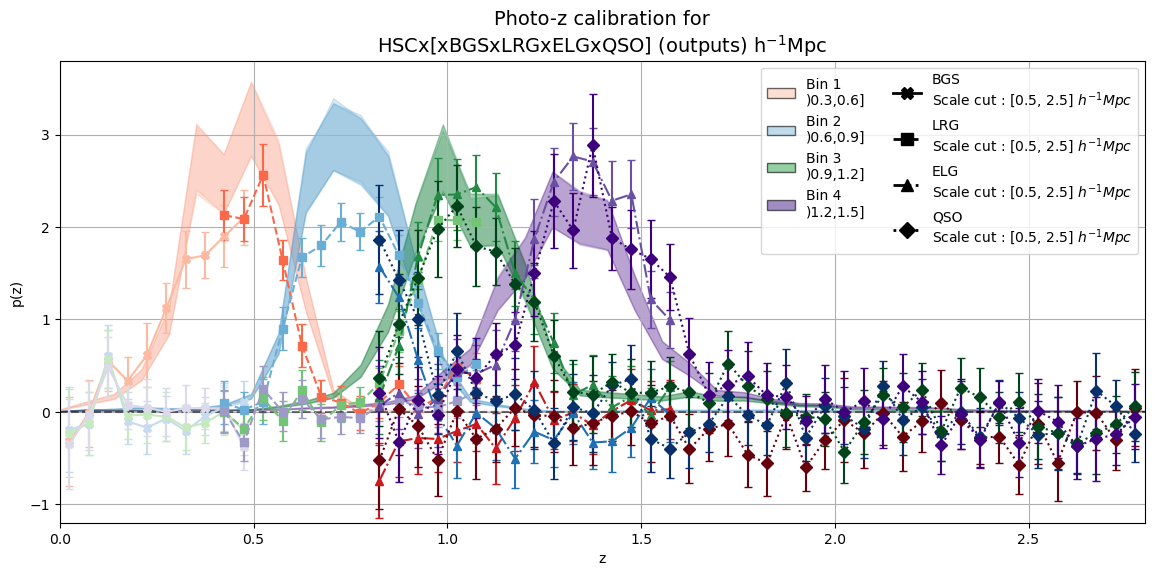

In [50]:
importlib.reload(inference)
ncurves = 0
tracers = ['BGS_ANY', 'LRG', 'ELG_LOPnotqso', 'QSO'] #'LRG', 'ELGnotqso', 'QSO'] #'LRG', 'ELGnotqso', 'QSO']#'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELG_LOPnotqso' : 'ELG',
    'QSO' : 'QSO',
}

# tomographic binning...
bins_hsc = np.arange(0.3, 1.8, 0.3)

colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['X', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']

tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, ax = plt.subplots(figsize=(14, 6))

# only looking at tomo 3
tomo_interest = [1,2,3,4]

scale_cuts = [[.5, 2.5]] # in Mpc/h #[[0.2, 2.5], [0.2, 2.5], [0.2, 5], [0.5, 5]]
if scale_cuts is not None and len(scale_cuts) == 1:
    scale_cuts = [scale_cuts[0] for _ in range(len(tracers))]

title = 'Photo-z calibration for\nHSCx['
for n in range(len(tracers)):
    t = tracers[n]
    print(f"Tracer {t}")
    bins_tracer = cf.CorrFileReader(
        path_dictionary['DESI_NGC'],
        ).get_bins(t)
    zval = bins_tracer[:-1] + np.diff(bins_tracer) / 2
    print(zval)
    range_tracer = [bins_tracer[0], bins_tracer[-1]]
    mask = (tomo_bin_dnnz[:, 0] >= min(bins_tracer)) & (tomo_bin_dnnz[:, 0] <= max(bins_tracer))
    mids = tomo_bin_dnnz[:, 0]
    mask_mids = tomo_bin_dnnz[mask, 0]

    dnnz_list = []
    mu_list = []
    cov_list = []

    ids_to_skip = []
    nz = []
    nz_err = []

    for tomo in tomo_interest:
        print(f"Computing n(z) for tracer {t} and tomo bin {tomo}")
        tomo_nz, tomo_nz_err = inference.full_npz_tomo(
                path_dictionary=path_dictionary,
                scale_cuts=scale_cuts[n],
                tracer=t,
                tomo_bin=tomo,
                do_bias_correction=False,
                rebin=1,
                )
        nz.append(tomo_nz)
        nz_err.append(tomo_nz_err)
        
    area_ratio = []

    for outlier_idx in range(len(tomo_interest)):
        if max(range_tracer[0], bins_hsc[outlier_idx]) > min(range_tracer[1], bins_hsc[outlier_idx+1]):
            ids_to_skip.append(outlier_idx)

    for dnnz_idx in range(0, 4):
        ncurves += 1

        dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, dnnz_idx+1], mids)
        area_ratio.append(simpson(np.percentile(dnnz, 50, axis=0)[mask], x=mask_mids))

        if dnnz_idx in ids_to_skip:
            continue
        ax.fill_between(
            mids, 
            np.percentile(dnnz, 16, axis=0), 
            np.percentile(dnnz, 84, axis=0), 
            color=colormaps[dnnz_idx]((dnnz_idx+2)/5), 
            alpha=0.2
            )
        
    for x, j in enumerate(tomo_interest):
        if j in ids_to_skip and t=='QSO':
            continue
        mask = ~np.isnan(nz[x])
        #normalization = simpson(nz[x][mask], x=zval[mask])/area_ratio[x]
        #if normalization > 0:
        ax.errorbar(
            x=zval[mask], 
            y=nz[x][mask],#/normalization,
            yerr=nz_err[x][mask],#/normalization, 
            capsize=3,
            marker=markers[n], 
            linestyle=linestyles[n],
            markersize=6,   
            alpha=1,
            color=colormaps[j-1]((n+1)/4),
            )
        
    title+= f'x{tracer_trad[tracers[n]]}'

#ax.plot(
#    np.linspace(0, 7, 100),
#    normalized_pdf_tail, 
#    color='black', 
#    linestyle='--', 
#    label='Best sum PDF tail',
#    alpha=1,
#    linewidth=2,
#)

title+=f'] ({ROOT.name}) ' +r'$\rm{h}^{-1}\rm{Mpc}$'
ax.set_xlabel('z')
ax.set_ylabel('p(z)')

legend_elements = []

for bin_id in tomo_interest:
    patch = Patch(
        facecolor=colormaps[bin_id-1]((bin_id)/len(bins_hsc)),
        alpha=0.6,
        edgecolor='black',
        label=f'Bin {bin_id}\n){bins_hsc[bin_id-1]:.1f},{bins_hsc[bin_id]:.1f}]',
    )
    legend_elements.append(patch)

for i, (marker, linestyle, tracer) in enumerate(zip(markers, linestyles, tracers)):
    element = Line2D(
        [0], 
        [0], 
        color='black', 
        marker=marker, 
        linestyle=linestyle, 
        markersize=8, 
        label=tracer_trad[tracer] + f'\nScale cut : [{scale_cuts[i][0]:.1f}, {scale_cuts[i][1]:.1f}] ' + r'$h^{-1}Mpc$', 
        linewidth=2
    )
    legend_elements.append(element)

ax.legend(
    handles=legend_elements, 
    loc='upper right', 
    ncol=2, 
    fontsize=10,
)

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.grid()
ax.set_title(title, fontsize=14)
ax.set_xlim(0, 2.8)
ax.set_ylim(-1.2, 3.8)

Magnification bias corrections :

$ w_{sp}(z_i) = n_p(z_i) b_p(z_i) b_s(z_i) w_{\mathrm{DM}}(z_i) + 
b_s(z_i) \alpha_p(z_i) \sum_{j>i} \left[ D_{ij} n_p(z_j) \right] + 
b_p(z_i) \alpha_s(z_i) \sum_{j>i} \left[ D_{ij} n_p(z_i) \right] $  

$ \frac{w_{sp}(z_i)}{\Delta z\sqrt{w_{pp}(z_i)w_{ss}(z_i)}} = n_p(z_i) + 
\frac{\alpha_p(z_i)}{b_p(z_i)} \sum_{j>i} \left[ D_{ij}^n n_p(z_j) \right] + 
\frac{\alpha_s(z_i)}{b_s(z_i)} \sum_{j>i} \left[ D_{ij}^n n_p(z_i) \right] $  

$ D_{ij}^n = \frac{D_{ij}}{w_{\mathrm{DM}}(z_i)} $  

$ D_{ij} = \frac{3 H_0^2 \Omega_m}{c^2} w_{\mathrm{DM}}(z_i)
\frac{\chi(z_j)\left[ \chi(z_j) - \chi(z_i) \right]}{a(z_i) \chi(z_j)} \Delta \chi_j $  

### Gaussian Mixture